# Imports and loading dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, RocCurveDisplay

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

pd.set_option('display.max_columns', None)


train_df = pd.read_csv('/Users/gabrielaslomiany/PyCharmMiscProject/Smartphone-Addiction-Kaggle/smartphone_addiction_data/train.csv')
test_df = pd.read_csv('/Users/gabrielaslomiany/PyCharmMiscProject/Smartphone-Addiction-Kaggle/smartphone_addiction_data/test.csv')

print('train shape:', train_df.shape)
print('test shape:', test_df.shape)
train_df.head()

# Checking training set

In [2]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  str    
 11  stress_level             636221 non-null  str    
 12  academic_work_impact     647145 non-null  str    
 13  addicted_label           691369 non-null  int64  
dtypes: float64(9), 

In [3]:
train_df.describe()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,691369.000000,662440.000000,595515.000000,557374.000000,564548.000000,639851.000000,646889.000000,623785.000000,610659.000000,579306.000000,691369.000000
mean,345684.000000,26.615408,7.640865,2.471038,1.459265,2.366971,6.804334,145.894900,102.636781,9.479866,0.709424
std,199581.183467,5.153162,2.721446,1.316137,0.934552,1.258797,1.234512,65.917556,48.093970,2.856006,0.454028
min,0.000000,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.000000
25%,172842.000000,22.000000,5.480000,1.450000,0.700000,1.360000,5.780000,93.000000,64.000000,7.280000,0.000000
50%,345684.000000,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,1.000000
75%,518526.000000,31.000000,9.840000,3.370000,2.090000,3.200000,7.870000,204.000000,145.000000,11.750000,1.000000
max,691368.000000,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,1.000000


In [4]:
print(train_df['stress_level'].unique())

<StringArray>
['Medium', 'Low', 'High', nan]
Length: 4, dtype: str


In [5]:
print(train_df['academic_work_impact'].unique())

<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str


In [6]:
print(train_df['gender'].unique())

<StringArray>
['Male', 'Female', 'Other', nan]
Length: 4, dtype: str


# EDA

### Missing data

In [7]:
print(train_df.columns)
print()
print(test_df.columns)

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'gender', 'stress_level', 'academic_work_impact', 'addicted_label'],
      dtype='str')

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'gender', 'stress_level', 'academic_work_impact'],
      dtype='str')


test set is missing one column `addicted_label' - which is target variable

In [8]:
missing_train = train_df.isna().sum()
missing_test = test_df.isna().sum()

missing_df = pd.DataFrame({'training_set': missing_train, 'test_set': missing_test})
missing_df

,training_set,test_set
academic_work_impact,44224,25721.0
addicted_label,0,NaN
age,28929,17138.0
app_opens_per_day,80710,25705.0
daily_screen_time_hours,95854,32788.0
gaming_hours,126821,59420.0
gender,29034,14212.0
id,0,0.0
notifications_per_day,67584,34221.0
sleep_hours,44480,22455.0


In [9]:
print('train dtypes ----------------------')
print(train_df.dtypes)
print()
print('test dtypes -----------------------')
print(test_df.dtypes)

train dtypes ----------------------
id                           int64
age                        float64
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day      float64
app_opens_per_day          float64
weekend_screen_time        float64
gender                         str
stress_level                   str
academic_work_impact           str
addicted_label               int64
dtype: object

test dtypes -----------------------
id                           int64
age                        float64
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day      float64
app_opens_per_day          float64
weekend_screen_time        float64
gender                         str
stress_level                   str
aca

### Plot of addicted / not addicted

In [10]:
addiction = train_df['addicted_label'].value_counts()
proportion = train_df['addicted_label'].value_counts(normalize=True)

addiction_df = pd.DataFrame({'addiction':addiction, 'proportion':proportion})
addiction_df

,addiction,proportion
addicted_label,,
1,490474,0.709424
0,200895,0.290576


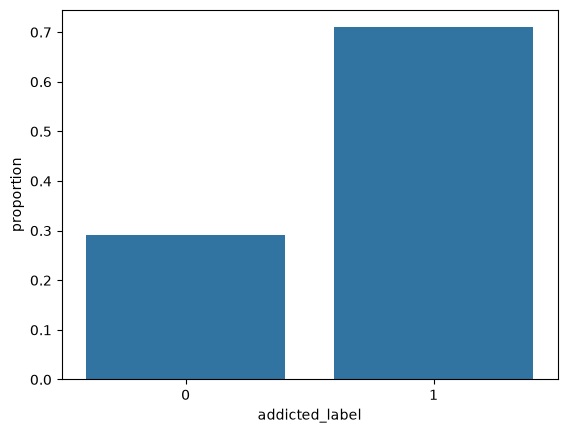

In [11]:
sns.barplot(x='addicted_label', y='proportion', data=addiction_df)
plt.show()

Target is imbalanced but not severely

### Checking unique values for categorical columns

In [12]:
for col in ['gender', 'stress_level', 'academic_work_impact']:
    print(col, '->', train_df[col].unique())

gender -> <StringArray>
['Male', 'Female', 'Other', nan]
Length: 4, dtype: str
stress_level -> <StringArray>
['Medium', 'Low', 'High', nan]
Length: 4, dtype: str
academic_work_impact -> <StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str


### Feature distributions

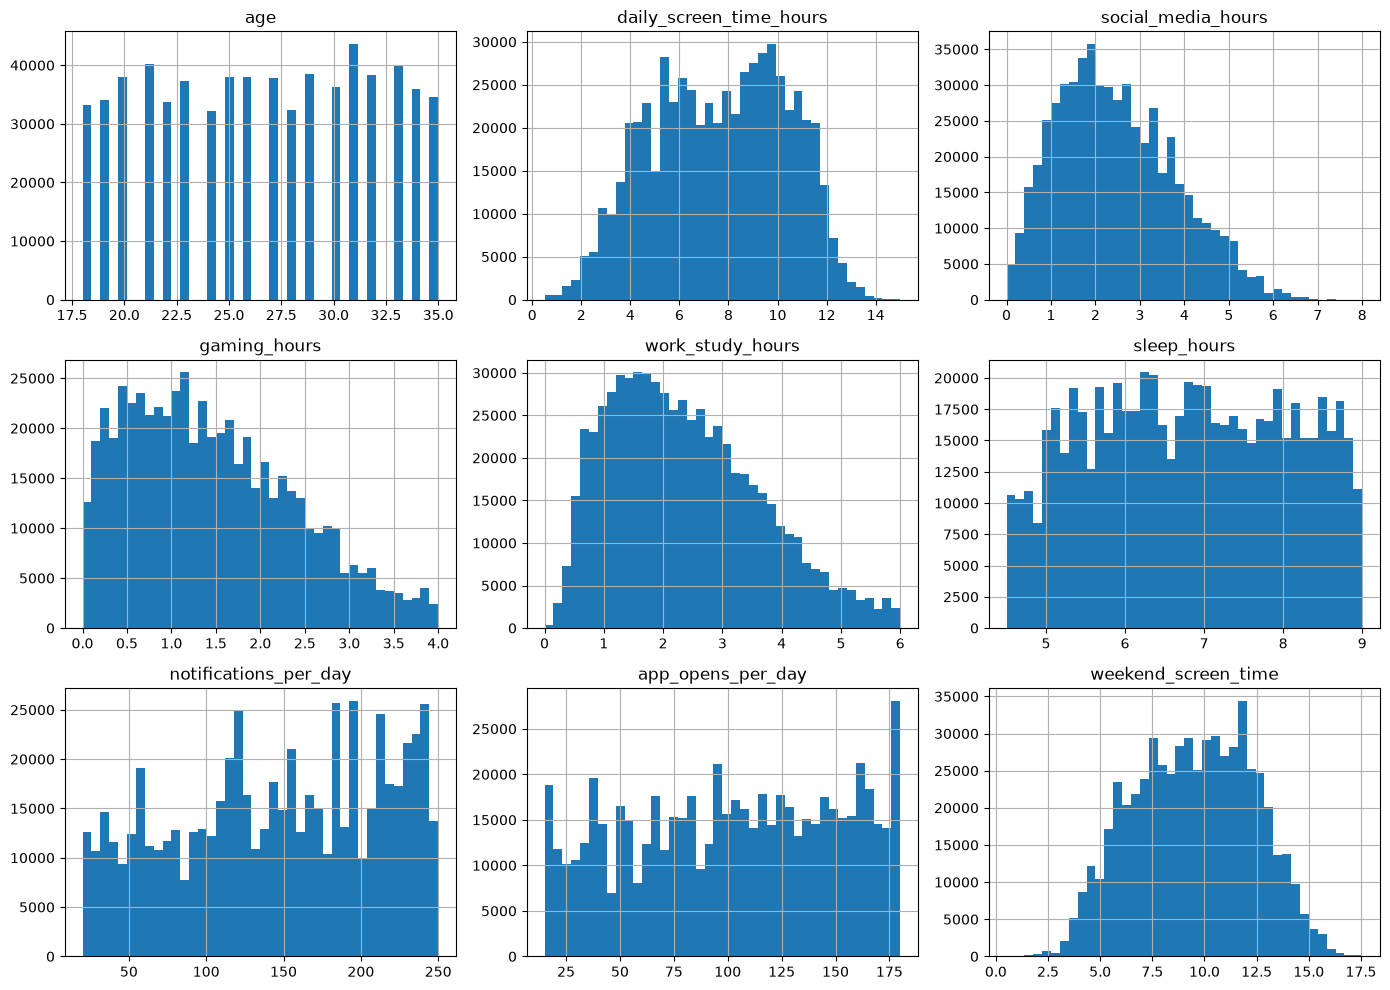

In [13]:
numeric_features = [
    'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
    'work_study_hours', 'sleep_hours', 'notifications_per_day',
    'app_opens_per_day', 'weekend_screen_time',
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.ravel(), numeric_features):
    train_df[col].hist(bins=40, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

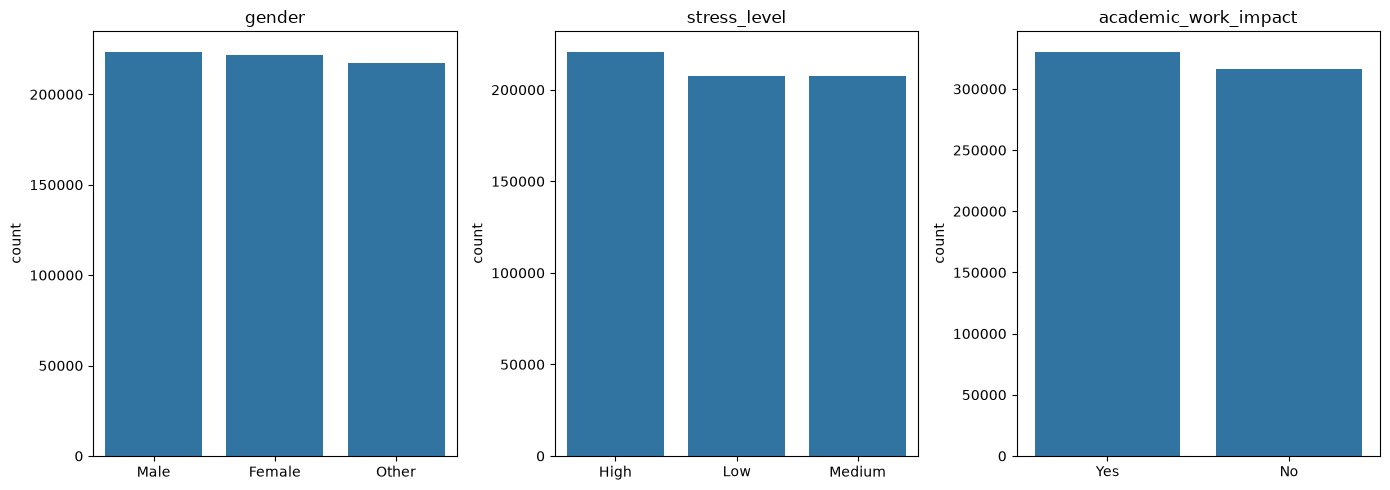

In [14]:
categorical_features = ['gender', 'stress_level', 'academic_work_impact']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes.ravel(), categorical_features):
    counts = train_df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()

# Preprocessing pipelines
Handling NaN

In [15]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

In [16]:
nominal_features = ['gender']
ordinal_features = ['stress_level']
binary_features = ['academic_work_impact']

stress_order = ['Low', 'Medium', 'High']
impact_order = ['No', 'Yes']

# nominal_features (gender): no natural order, imputes missing with the most frequent category then one-hot encodes
nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

# ordinal_features (stress_level): has a natural order, imputes missing with the most frequent category then encodes Low/Medium/High as 0/1/2
ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[stress_order])),
])

# binary_features (academic_work_impact): two categories, imputes missing with the most frequent category then encodes No/Yes as 0/1
binary_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[impact_order])),
])

# combines the three encoders above, each applied to its own column(s)
categorical_pipeline = ColumnTransformer(transformers=[
    ('nominal', nominal_pipeline, nominal_features),
    ('ordinal', ordinal_pipeline, ordinal_features),
    ('binary', binary_pipeline, binary_features),
])

In [17]:
# combines the numeric pipeline and the categorical pipeline (which itself combines nominal/ordinal/binary) into one preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, nominal_features + ordinal_features + binary_features),
])

In [18]:
feature_columns = numeric_features + nominal_features + ordinal_features + binary_features

X = train_df[feature_columns]
y = train_df['addicted_label']
X_test = test_df[feature_columns]

# stratify on y since the target is imbalanced (~71/29 split, see above)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# fit the preprocessor (imputers + encoders/scaler) on the training split only, then reuse it to transform val/test - avoids leaking val/test statistics into training
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print('missing values in X_train_processed:', np.isnan(X_train_processed).sum())
print('missing values in X_val_processed:', np.isnan(X_val_processed).sum())
print('missing values in X_test_processed:', np.isnan(X_test_processed).sum())

missing values in X_train_processed: 0
missing values in X_val_processed: 0
missing values in X_test_processed: 0


# Models

In [19]:
results = {}
fitted_pipelines = {}

def evaluate(name, pipeline):
    pipeline.fit(X_train, y_train)
    val_pred = pipeline.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, val_pred)
    results[name] = auc
    fitted_pipelines[name] = pipeline
    print(f'{name:12s} validation ROC-AUC: {auc:.4f}')
    return pipeline

In [20]:
preprocessor_linear = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('nom', nominal_pipeline, nominal_features),
    ('ord', ordinal_pipeline, ordinal_features),
    ('bin', binary_pipeline, binary_features),
])

logreg_pipe = Pipeline([
    ('pre', preprocessor_linear),
    ('clf', LogisticRegression(max_iter=1000, random_state=42)),
])
evaluate('LogReg', logreg_pipe)

LogReg       validation ROC-AUC: 0.9102


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['age','daily_screen_time_hours','social_media_hours',...,'gender', 'stress_level','academic_work_impact']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``re

In [21]:
preprocessor_tree = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('nom', nominal_pipeline, nominal_features),
    ('ord', ordinal_pipeline, ordinal_features),
    ('bin', binary_pipeline, binary_features),
])

rf_pipe = Pipeline([
    ('pre', preprocessor_tree),
    ('clf', RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)),
])
evaluate('RF', rf_pipe)

RF           validation ROC-AUC: 0.9411


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['age','daily_screen_time_hours','social_media_hours',...,'gender', 'stress_level','academic_work_impact']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``re

In [22]:
xgb_pipe = Pipeline([
    ('pre', preprocessor_tree),
    ('clf', XGBClassifier(
        n_estimators=400, tree_method='hist', eval_metric='auc',
        random_state=42,
    )),
])
evaluate('XGB', xgb_pipe)

XGB          validation ROC-AUC: 0.9623


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['age','daily_screen_time_hours','social_media_hours',...,'gender', 'stress_level','academic_work_impact']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``re

        val_roc_auc
XGB        0.962297
RF         0.941055
LogReg     0.910246


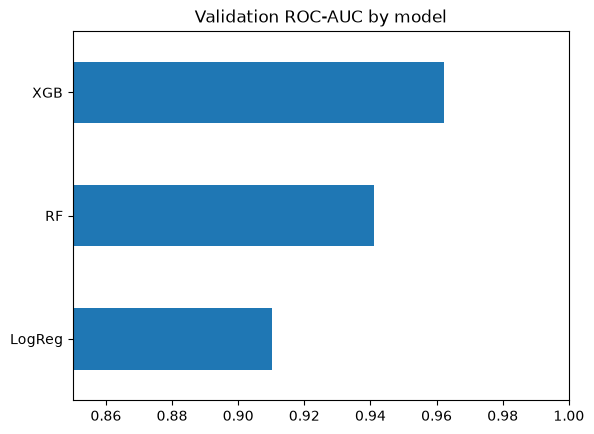

In [23]:
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['val_roc_auc']).sort_values('val_roc_auc', ascending=False)
print(results_df)

results_df['val_roc_auc'].plot(kind='barh', title='Validation ROC-AUC by model')
plt.gca().invert_yaxis()
plt.xlim(0.85, 1.0)
plt.show()

# Hyperparameter tuning

### Random Forest Tuning

In [24]:
# from scipy.stats import randint
#
# # param names need the 'clf__' prefix since rf_pipe is a Pipeline (preprocessing + classifier), not a bare estimator
# # RandomizedSearchCV samples n_iter combinations instead of trying every combination (like GridSearchCV) -
# # much cheaper on ~550k training rows while still covering a wide hyperparameter space
# params_rf = {
#               'clf__n_estimators': [200, 300, 400, 500, 600],
#               'clf__max_depth': [None, 10, 15, 20, 25],
#               'clf__min_samples_split': [2, 5, 10, 20],
#               'clf__min_samples_leaf': [1, 5, 10, 20],
#               'clf__max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
#             }
#
# # scoring set to roc_auc to match the metric used to compare models above (RandomizedSearchCV defaults to accuracy)
# random_rf = RandomizedSearchCV(
#     estimator=rf_pipe,
#     param_distributions=params_rf,
#     n_iter=10,
#     cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
#     scoring='roc_auc',
#     n_jobs=-1,
#     random_state=42,
#     verbose=1,
#     return_train_score=True,
# )
#
# random_rf.fit(X_train, y_train)
#
# best_hyperparams = random_rf.best_params_
# print('Best hyperparameters:\n', best_hyperparams)

### XGB Tuning

In [25]:
xgb_search_pipe = Pipeline([
    ('pre', preprocessor_tree),
    ('clf', XGBClassifier(tree_method='hist', eval_metric='auc', random_state=42)),
])

param_dist = {
    'clf__n_estimators': [200, 300, 400, 500],
    'clf__max_depth': [3, 4, 5, 6],
    'clf__learning_rate': [0.02, 0.03, 0.05, 0.1],
    'clf__subsample': [0.7, 0.85, 1.0],
    'clf__colsample_bytree': [0.7, 0.85, 1.0],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    xgb_search_pipe, param_dist, n_iter=10, cv=cv,
    scoring='roc_auc', random_state=42, n_jobs=1, verbose=1,
)
search.fit(X_train, y_train)

print('Best CV ROC-AUC:', search.best_score_)
print('Best params:', search.best_params_)

xgb_tuned = search.best_estimator_
val_auc = roc_auc_score(y_val, xgb_tuned.predict_proba(X_val)[:, 1])
print('Tuned XGB validation ROC-AUC:', val_auc)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV ROC-AUC: 0.9610177618390825
Best params: {'clf__subsample': 1.0, 'clf__n_estimators': 400, 'clf__max_depth': 6, 'clf__learning_rate': 0.1, 'clf__colsample_bytree': 0.85}
Tuned XGB validation ROC-AUC: 0.9605431989821999


In [26]:
results['XGB_tuned'] = val_auc
fitted_pipelines['XGB_tuned'] = xgb_tuned
print(f'XGB_tuned    validation ROC-AUC: {val_auc:.4f}')

XGB_tuned    validation ROC-AUC: 0.9605


           val_roc_auc
XGB           0.962297
XGB_tuned     0.960543
RF            0.941055
LogReg        0.910246


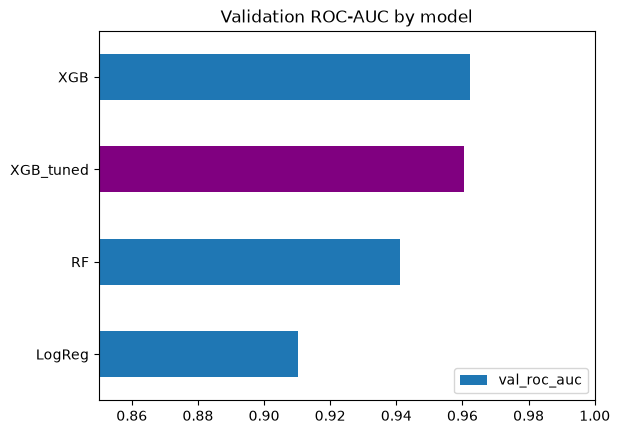

In [32]:
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['val_roc_auc']).sort_values('val_roc_auc', ascending=False)
print(results_df)

colors = ['purple' if name == 'XGB_tuned' else 'tab:blue' for name in results_df.index]
results_df['val_roc_auc'].plot(kind='barh', title='Validation ROC-AUC by model', color=colors)
plt.gca().invert_yaxis()
plt.xlim(0.85, 1.0)
plt.show()

Observation: Tuned XGB scored less than base XGB, therefore I will make prediction on test set using XGB with 0.962297.

In [28]:
final_pipe = xgb_pipe
final_pipe.fit(X, y)

test_pred = final_pipe.predict_proba(test_df[feature_columns])[:, 1]

submission = pd.DataFrame({
    'id': test_df['id'],
    'addicted_label': test_pred,
})

print(submission.shape)
print(submission['addicted_label'].describe())
submission.head()


(296302, 2)
count    296302.000000
mean          0.709476
std           0.370748
min           0.000013
25%           0.387153
50%           0.950927
75%           0.999707
max           1.000000
Name: addicted_label, dtype: float64


,id,addicted_label
0,691369,0.999498
1,691370,0.958775
2,691371,0.912950
3,691372,0.987666
4,691373,0.999490


In [29]:
# submission.to_csv('submission.csv', index=False)
# print('Saved submission.csv')